# Interprovincial Migration and Housing Price Growth in Canada (2010–2025)

### Project Overview

This notebook presents an exploratory empirical analysis examining the relationship between interprovincial migration rates and housing price growth across Canadian provinces from 2010 to 2025.

The primary objective is to investigate whether higher net migration rates are associated with stronger housing price index (HPI) growth at the provincial level.

### Data Sources

The analysis uses publicly available data from Statistics Canada:

- New Housing Price Index (monthly data, aggregated to annual values)
- Interprovincial migration flows (annual)
- Provincial population estimates (quarterly, used to construct migration rates)

A province–year panel dataset is constructed by merging these sources.

### Methodology

The workflow in this notebook includes:

- Cleaning and transforming raw CSV data
- Constructing annual HPI growth rates
- Computing migration rates (net migration divided by provincial population)
- Merging datasets into a balanced panel
- Conducting descriptive statistics and graphical analysis
- Exploring the linear relationship between migration and housing price growth

This notebook emphasizes transparent data manipulation and reproducibility, with all steps shown explicitly in Python (pandas, matplotlib, NumPy).

### Scope

This analysis focuses on descriptive and exploratory relationships. The goal is to assess whether a meaningful association exists between teh variables of interest, migration rates and HPI.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

# Section 1: Collecting and Organizing Data

In [ ]:
# Creating dataframe and adding HPI as well as HPI growth sections
main_df = pd.read_csv('data/HPI_data.csv', skiprows=10, skipfooter=25, engine='python')
main_df = main_df.rename(columns={'Unnamed: 0' : 'Geography', 'Unnamed: 1':'Month', 'Index, 201612=100':'HPI'})
main_df['Geography'] = main_df['Geography'].ffill()
main_df['Month'] = pd.to_datetime(main_df['Month'], format="%B %Y")
main_df['Year'] = main_df['Month'].dt.year
annual_df = main_df.groupby(['Geography', 'Year'])['HPI'].mean().reset_index()
annual_df['HPI_growth'] = annual_df.groupby('Geography')['HPI'].pct_change()
print(annual_df.head())

In [ ]:
# Pulling in migration data and restructuring it
migration_df = pd.read_csv('data/Migration_data.csv', skiprows=10, skipfooter=15, engine='python')
migration_df = migration_df.rename(columns={'Unnamed: 0':'Geography', 'Unnamed: 1': 'Period', 'Persons': 'Net_Mgr'})
migration_df['Geography'] = migration_df['Geography'].ffill()
migration_df['Period'] = migration_df['Period'].str[-4:].astype(int)
migration_df = migration_df.rename(columns={'Period': 'Year'})
migration_df['Net_Mgr'] = migration_df['Net_Mgr'].str.replace(',', '').astype(float)
print(migration_df.head())

In [ ]:
# Merging infomation about HPI growth and Migrations into the same table
panel_df = annual_df.merge(migration_df, on=['Geography', 'Year'], how='inner')
print(panel_df.head())

In [ ]:
# Pulling in population data and restructuring it
df_pop = pd.read_csv('data/Population_data.csv', skiprows=10, skipfooter=14, engine='python')
df_pop = df_pop.rename(columns={'Unnamed: 0':'Quarter', 'Persons':'Newfoundland and Labrador', 'Unnamed: 2':'Prince Edward Island', 'Unnamed: 3':'Nova Scotia', 'Unnamed: 4':'New Brunswick', 'Unnamed: 5':'Quebec', 'Unnamed: 6':'Ontario', 'Unnamed: 7':'Manitoba', 'Unnamed: 8':'Saskatchewan', 'Unnamed: 9':'Alberta', 'Unnamed: 10':'British Columbia'})
long_pop = df_pop.melt(id_vars='Quarter', var_name='Geography', value_name='Population')
long_pop = long_pop.reset_index(drop=True)
long_pop['Population'] = long_pop['Population'].astype(str).str.replace(',', '').astype(int)
long_pop = long_pop[long_pop['Quarter'].astype(str).str.contains('Q3')]
long_pop = long_pop.rename(columns={'Quarter': 'Year'})
long_pop['Year'] = long_pop['Year'].astype(str).str[-4:].astype(int)
print(long_pop.head())

In [6]:
# Merging population information with the main table to find weighted migration rate
panel_df = panel_df.merge(long_pop, on=['Geography', 'Year'], how='inner')
panel_df['Mgr_Rate'] = panel_df['Net_Mgr'] / panel_df['Population'] 
print(panel_df.head())

  Geography  Year        HPI  HPI_growth  Net_Mgr  Population  Mgr_Rate
0   Alberta  2010  92.491667         NaN  -3271.0     3732104 -0.000876
1   Alberta  2011  92.875000    0.004145   8443.0     3787705  0.002229
2   Alberta  2012  94.050000    0.012651  27652.0     3871947  0.007142
3   Alberta  2013  96.641667    0.027556  38598.0     3978532  0.009702
4   Alberta  2014  99.958333    0.034319  35382.0     4081271  0.008669


In [7]:
# Doing a final check for missing values in teh tables
print(panel_df.isna().sum())

Geography      0
Year           0
HPI            0
HPI_growth    10
Net_Mgr        0
Population     0
Mgr_Rate       0
dtype: int64


Apperance of 10 missing values in the HPI_growth column can be explained by the fact that no data for years before 2010 is considered, so it is not possible to calculate weighted difference between years. 

# Section 2: Summary Statistics and Visualizing Data
Undersanding what the data looks like, how it correlates to one another, and how to make sense of it. 

## Dataset Summary

In [8]:
print(panel_df.describe())

              Year         HPI  HPI_growth       Net_Mgr    Population  \
count   160.000000  160.000000  150.000000    160.000000  1.600000e+02   
mean   2017.500000  105.595833    0.020816     20.050000  3.705272e+06   
std       4.624246   13.273137    0.033431  11607.297429  4.377610e+06   
min    2010.000000   80.783333   -0.021228 -42689.000000  1.416440e+05   
25%    2013.750000   97.997917    0.001043  -4912.250000  7.695470e+05   
50%    2017.500000  100.475000    0.009747   -921.000000  1.240610e+06   
75%    2021.250000  109.868750    0.029202   1946.750000  5.023071e+06   
max    2025.000000  146.550000    0.155770  48394.000000  1.625826e+07   

         Mgr_Rate  
count  160.000000  
mean     0.000106  
std      0.004152  
min     -0.009776  
25%     -0.002510  
50%     -0.000407  
75%      0.002167  
max      0.011426  


In [9]:
print(panel_df[['HPI_growth', 'Net_Mgr']].corr())
print(panel_df[['HPI_growth', 'Mgr_Rate']].corr())

print('Signals a weak but noticable positive correlation.')
print('Correlation between HPI_growth and Mgr_Rate is a more accurate measure since it takes into account the size of the population for each province as well.')

            HPI_growth  Net_Mgr
HPI_growth     1.00000  0.10963
Net_Mgr        0.10963  1.00000
            HPI_growth  Mgr_Rate
HPI_growth    1.000000  0.193851
Mgr_Rate      0.193851  1.000000
Signals a weak but noticable positive correlation.
Correlation between HPI_growth and Mgr_Rate is a more accurate measure since it takes into account the size of the population for each province as well.


## Visualizing Distributions
Trying to find anomalies in the data, checking distribution etc.

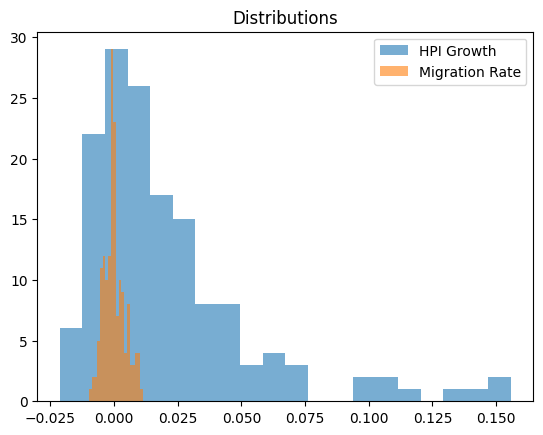

In [10]:
plt.hist(panel_df['HPI_growth'], bins=20, alpha=0.6, label='HPI Growth')
plt.hist(panel_df['Mgr_Rate'], bins=20, alpha=0.6, label='Migration Rate')

plt.legend()
plt.title('Distributions')
plt.show()

#### For HPI Growth:
Most of the values if HPI Growth rate are concentrated between -1% and 2.5% 
The data is more skewed to the right, the tail extends all the way upto just over 15%, showing that occasinally some provinces have large hikes in prices. 

#### For Migration Rate:
Values remain within -1% and 1% showing that there rarely sudden increases in migration rates, with most province-year combinations being very very small values, well close to 0 percent. 

## Time Series Visualization

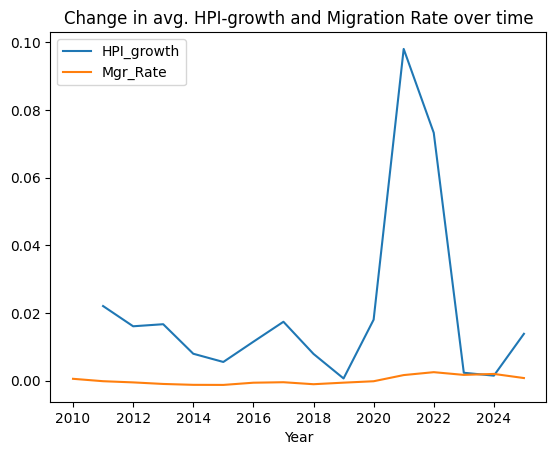

In [11]:
# Plotting averages over time
avg_by_year = panel_df.groupby('Year')[['HPI_growth', 'Mgr_Rate']].mean()

avg_by_year.plot(kind='line')
plt.title('Change in avg. HPI-growth and Migration Rate over time')
plt.show()

#### Interpretation
Massive hike in prices (big change in HPI), around 2021-2022 that can be explain by rise in pandemic-era prices due factors such as lower interest rare, demand surge etc. Migration rates also rose during this period, but very modest change in comparison to large increase in HPI growth, indicating that migration alone may not have been the core factor affecting HPI. 

To get a better sense of how two move over time, we will consider using different scales. 

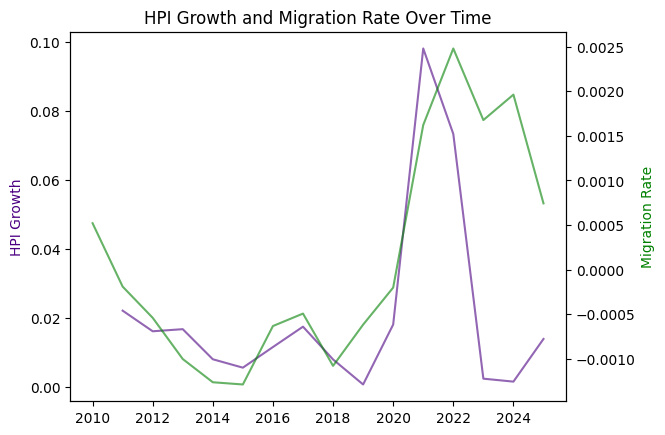

In [12]:
fig, ax1 = plt.subplots()

ax1.plot(avg_by_year.index, avg_by_year['HPI_growth'], color='indigo', alpha=0.6, label='HPI_growth')
ax1.set_ylabel('HPI Growth', color='indigo')

ax2 = ax1.twinx()
ax2.plot(avg_by_year.index, avg_by_year['Mgr_Rate'], color='green', alpha=0.6, label='Migration Rate')
ax2.set_ylabel('Migration Rate', color='green')

plt.title('HPI Growth and Migration Rate Over Time')
plt.show()

## Province-wise Analysis
Seeing relation between variables across each individual province being considered. 

In [13]:
print(panel_df.groupby('Geography')[['HPI_growth', 'Mgr_Rate']].corr())

                                      HPI_growth  Mgr_Rate
Geography                                                 
Alberta                   HPI_growth    1.000000  0.090024
                          Mgr_Rate      0.090024  1.000000
British Columbia          HPI_growth    1.000000  0.747150
                          Mgr_Rate      0.747150  1.000000
Manitoba                  HPI_growth    1.000000  0.451235
                          Mgr_Rate      0.451235  1.000000
New Brunswick             HPI_growth    1.000000  0.676213
                          Mgr_Rate      0.676213  1.000000
Newfoundland and Labrador HPI_growth    1.000000  0.556220
                          Mgr_Rate      0.556220  1.000000
Nova Scotia               HPI_growth    1.000000  0.385759
                          Mgr_Rate      0.385759  1.000000
Ontario                   HPI_growth    1.000000  0.173022
                          Mgr_Rate      0.173022  1.000000
Prince Edward Island      HPI_growth    1.000000  0.4503

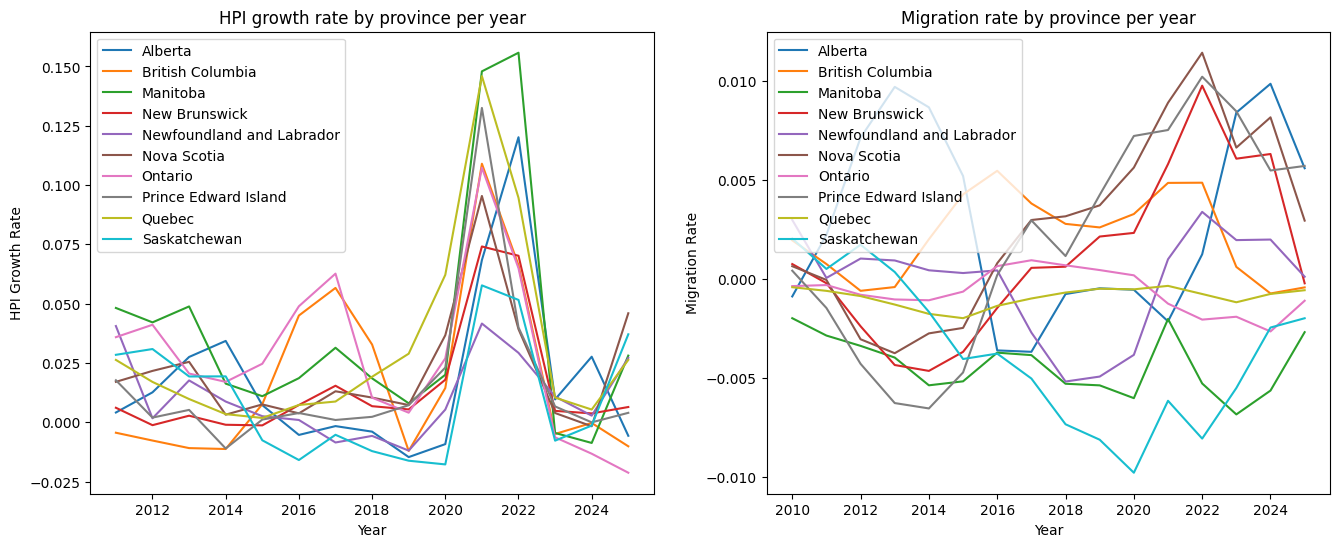

In [14]:
# Creating a graph where each line represnt the HPI growth rate of each of the provinces over time. 

fig, axes = plt.subplots(1, 2, figsize=(16,6))
# One row, two columns

for province in panel_df['Geography'].unique():
    subset = panel_df[panel_df['Geography'] == province]
    axes[0].plot(subset['Year'], subset['HPI_growth'], label=province)

axes[0].set_title('HPI growth rate by province per year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('HPI Growth Rate')
axes[0].legend(loc='upper left')

for province in panel_df['Geography'].unique():
    subset = panel_df[panel_df['Geography'] == province]
    axes[1].plot(subset['Year'], subset['Mgr_Rate'], label=province)

axes[1].set_title('Migration rate by province per year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Migration Rate')
axes[1].legend(loc='upper left')

plt.show()



#### Interpretation
All provinces saw massive rise in prices around during the COVID Period (2021-2022), with some varibiltiy prior to that. 
For migration rates, most provinces have shown positive trends, with exceptoin fo Saskatchewan which has had serious declines since 2016.

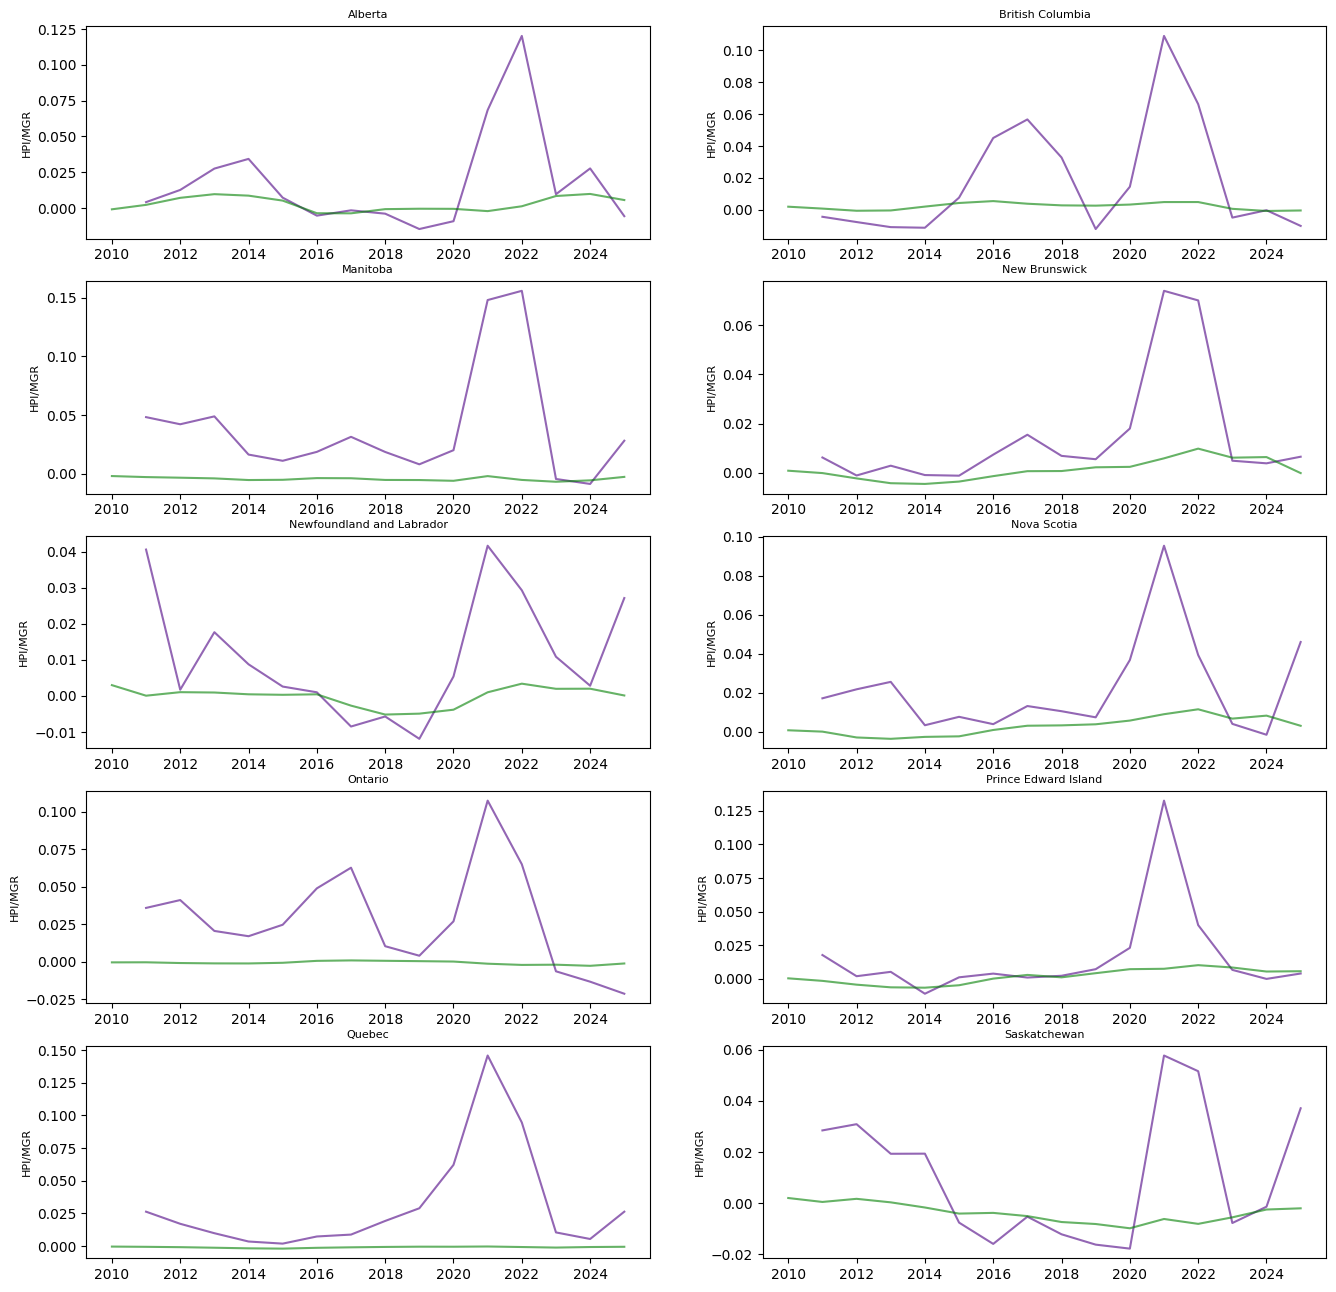

In [15]:
# Plotting graphs for each of the provinces sepepartely. 

all_provinces = []
for province in panel_df['Geography'].unique():
    all_provinces = all_provinces + [province]

fig, axes = plt.subplots(5, 2, figsize=(16,16))
axes = axes.flatten()

for i in range(len(all_provinces)):
    subset = panel_df[panel_df['Geography'] == all_provinces[i]]
    axes[i].set_title(f'{all_provinces[i]}', fontsize=8)
    axes[i].plot(subset['Year'], subset['HPI_growth'], alpha=0.6, color='indigo', label='HPI_growth')
    axes[i].plot(subset['Year'], subset['Mgr_Rate'], alpha=0.6, color='green', label='Mgr_Rate')
    axes[i].set_ylabel('HPI/MGR', fontsize=8)

plt.show()

#### Interpretation 
Western provinces have shown more vairablitiy in HPI growth than Atlantic provinces, although the trend in both cases has had little correlation with the movements in migration rates.

## Regression Analysis
Finding cross-sectional relationship between the two variables. 

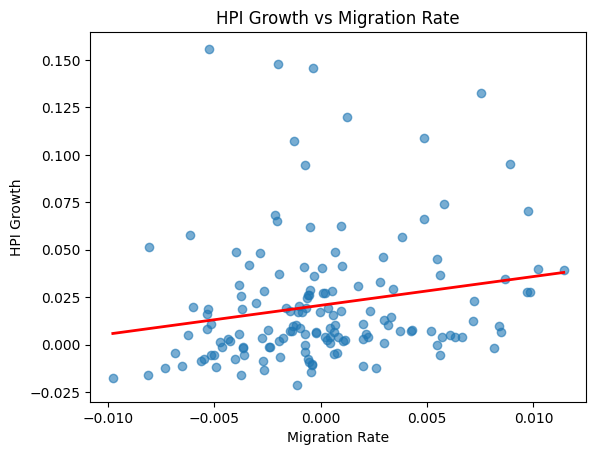

In [16]:
clean_df = panel_df[['Mgr_Rate','HPI_growth']].dropna()

x = clean_df['Mgr_Rate']
y = clean_df['HPI_growth']

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, alpha=0.6)
plt.plot(np.linspace(x.min(), x.max(), 100),
         m*np.linspace(x.min(), x.max(), 100) + b,
         color='red', linewidth=2)

plt.xlabel("Migration Rate")
plt.ylabel("HPI Growth")
plt.title("HPI Growth vs Migration Rate")

plt.show()

#### Interpretation
Higher migration rates are associated with higher HPI growth, but the relationship is weak, so the line is flat. The cloud of points is most spread out and so the line slopes upwards but just slightly.  The dispersion of observations around the fitted line indicates that migration alone explains only a small fraction of variation in housing prices.